# Lab 21 — Constant-Envelope Modulation and Modulation Quality: MSK, GMSK, GFSK, PAPR and EVM

**Companion to Chapter 9** (*Digital Modulation and Optimal Detection*), sections on continuous-phase modulation and on
measuring modulation quality.
**Time needed:** about 75 minutes. **Difficulty:** core.

Two questions decide what a radio can transmit. *Can the power amplifier run flat out?* Only if the signal has a constant
envelope, which is why GSM, Bluetooth, DECT and countless sensors use MSK, GMSK and GFSK. *How clean is the transmitted
constellation?* That is measured by the error vector magnitude (EVM), and it decides how many bits per symbol a
short-range link like Wi-Fi can use. This lab generates CPM signals with the same generator that drew Chapter 9's figures,
measures their spectra and 99% bandwidths, detects them three ways (coherent Laurent receiver, one-bit differential
detector, limiter-discriminator), compares envelope statistics (PAPR) across modulations, and then turns the
constellation into a diagnostic instrument: impairments, their EVM signatures, and an EVM budget for a 1024-QAM transmitter.
Library code: `commlib/cpm.py`.

### What you will learn
1. Build MSK, GMSK and GFSK from the CPM equation and read their phase trajectories and frequency pulses.
2. Measure spectra and 99% occupied bandwidth as a function of $BT$, and compare with QPSK.
3. See that MSK is OQPSK with half-sine pulses, and detect MSK/GMSK coherently with the main Laurent pulse.
4. Compare coherent, differential and discriminator receivers, and the ISI that small $BT$ brings.
5. Compare envelope fluctuations (PAPR CCDF) of GMSK, OQPSK, π/4-QPSK, QPSK and QAM.
6. Measure EVM, recognise impairments by their signature, and close an EVM budget.

### Prerequisites
Lab 2 (constellations, BER), Lab 3 (pulse shaping). Chapter 9, Sections on CPM and EVM.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Continuous-phase modulation: phase, frequency pulse, GFSK | yes |
| 2 | Spectra and 99% bandwidth | yes |
| 3 | MSK is OQPSK: the Laurent pulse | |
| 4 | Detecting MSK and GMSK: coherent, differential, discriminator | yes |
| 5 | Envelope and PAPR | |
| 6 | EVM: impairment signatures and a 1024-QAM budget | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps_
import commlib as cl
from commlib import cpm
from commlib import labkit as lk

rng = lk.setup(seed=21, lab="21")

Lab 21 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 21


## 1. Continuous-phase modulation: phase, frequency pulse, GFSK

A CPM signal has constant amplitude and a phase that integrates the data:

$$\tilde s(t)=\exp\Big(j\,2\pi h\sum_n a_n\,q(t-nT)\Big),\qquad q(t)=\int_{-\infty}^t g(\tau)\,d\tau,\quad q(\infty)=\tfrac12 .$$

Each bit $a_n = \pm 1$ moves the phase by $\pm\pi h$ in total. **MSK** is $h=\tfrac12$ with a rectangular one-bit frequency
pulse: the phase ramps by exactly ±90° per bit. **GMSK** smooths the rectangle with a Gaussian filter of bandwidth-time product
$BT$ (GSM: 0.3), so each bit's phase change is spread over two to three bits. **GFSK** is the same with $h \ne \tfrac12$
(Bluetooth BR: $h \approx 0.32$, BLE: $h \approx 0.5$, both $BT = 0.5$).

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

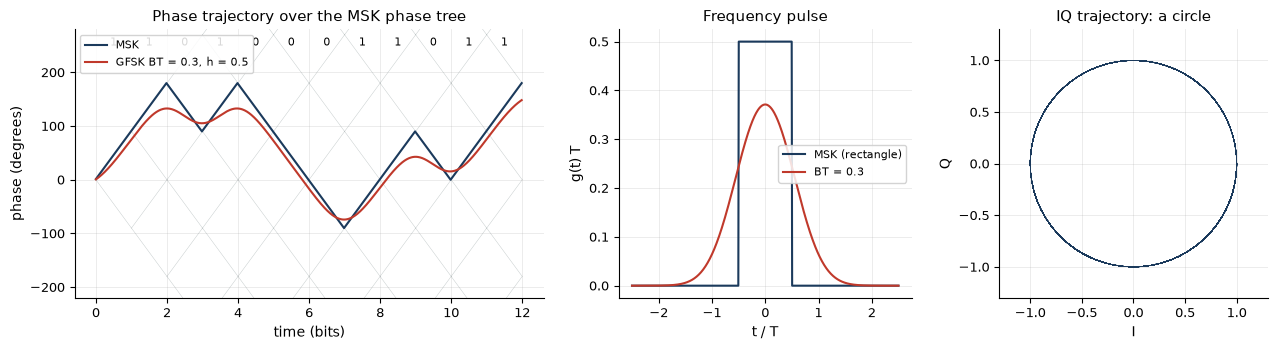

In [3]:
def cpm_demo(BT=0.3, h=0.5):
    bits = np.array([1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1])
    n = 64
    t = np.arange(len(bits) * n) / n
    f, ax = lk.fig((13, 3.6), 1, 3, gridspec_kw=dict(width_ratios=[1.6, 1, 1]))
    for k in range(len(bits)):                                   # MSK phase tree
        for m in range(-k, k + 1, 2):
            for d in (1, -1):
                ax[0].plot([k, k + 1], [m * 90, (m + d) * 90], color=lk.GRAY, lw=0.3, alpha=0.5)
    _, ph_msk = cpm.gmsk_baseband(bits, n, None)
    _, ph = cpm.gmsk_baseband(bits, n, BT, h)
    ax[0].plot(t, np.rad2deg(ph_msk), color=lk.NAVY, label="MSK")
    ax[0].plot(t, np.rad2deg(ph), color=lk.RED, label=f"GFSK BT = {BT:g}, h = {h:g}")
    for i, b in enumerate(bits):
        ax[0].text(i + 0.5, 250, str(b), ha="center", fontsize=8)
    ax[0].set_ylim(-220, 280); ax[0].set_xlabel("time (bits)"); ax[0].set_ylabel("phase (degrees)"); ax[0].legend(fontsize=8)
    ax[0].set_title("Phase trajectory over the MSK phase tree")
    tt = np.linspace(-2.5, 2.5, 600)
    ax[1].plot(tt, cpm.gmsk_freq_pulse(tt, None), color=lk.NAVY, label="MSK (rectangle)")
    ax[1].plot(tt, cpm.gmsk_freq_pulse(tt, BT), color=lk.RED, label=f"BT = {BT:g}")
    ax[1].set_xlabel("t / T"); ax[1].set_ylabel("g(t) T"); ax[1].legend(fontsize=8); ax[1].set_title("Frequency pulse")
    x, _ = cpm.gmsk_baseband(rng.integers(0, 2, 400), 16, BT, h)
    ax[2].plot(x.real, x.imag, color=lk.NAVY, lw=0.5)
    ax[2].set_aspect("equal"); ax[2].set_xlim(-1.3, 1.3); ax[2].set_ylim(-1.3, 1.3)
    ax[2].set_title("IQ trajectory: a circle"); ax[2].set_xlabel("I"); ax[2].set_ylabel("Q")
    lk.show(f)

lk.interact(cpm_demo, BT=lk.slider(0.3, 0.1, 1.0, 0.05, "BT"), h=lk.slider(0.5, 0.2, 1.0, 0.01, "modulation index h"))

**What you should see.** MSK's phase runs along the edges of the tree, ±90° per bit. GMSK with $BT = 0.3$ rounds the corners,
and after an alternating pattern (…0 1 0…) no longer reaches ±90° within the bit: the price of a narrow spectrum is
controlled intersymbol interference. Change $h$: with $h = 0.32$ (Bluetooth BR) each bit moves the phase only about 58°.
Whatever you choose, the IQ trajectory stays on the unit circle.

## 2. Spectra and 99% bandwidth

Continuity of phase makes MSK's sidelobes fall as $f^{-4}$, against $f^{-2}$ for rectangular QPSK; Gaussian filtering
makes them fall faster still. Chapter 9 quotes 99% power bandwidths of about $1.2R_b$ for MSK, $0.91R_b$ for GMSK $BT=0.3$, and
roughly $8R_b$ for rectangular QPSK.

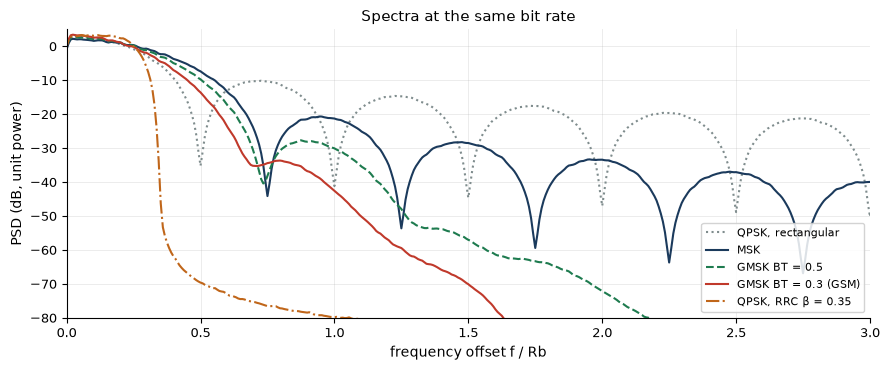

signal,99% bandwidth (× Rb),99.9% bandwidth (× Rb)
"QPSK, rectangular",7.90,14.86
MSK,1.19,2.85
GMSK BT = 0.5,1.03,1.31
GMSK BT = 0.3 (GSM),0.91,1.12
"QPSK, RRC β = 0.35",0.58,0.63


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

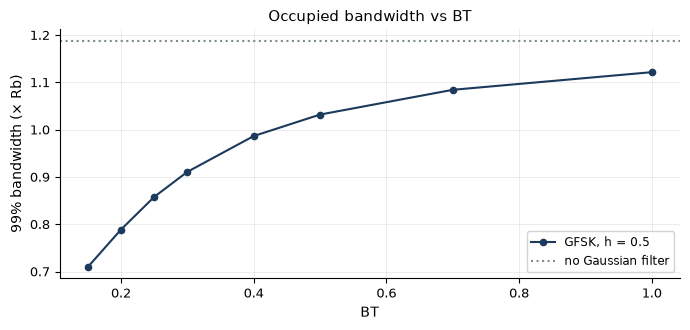

In [5]:
nb, n = 100_000, 16
bits = rng.integers(0, 2, nb)
qps = cl.get_constellation("qpsk").points[rng.integers(0, 4, nb // 2)]
x_rect = np.repeat(qps, 2 * n)
up = np.zeros(len(qps) * 2 * n, complex); up[::2 * n] = qps
x_rrc = sps_.fftconvolve(up, cl.rrc_taps(0.35, 2 * n, span=40))
items = [("QPSK, rectangular", x_rect, lk.GRAY, ":"), ("MSK", cpm.gmsk_baseband(bits, n, None)[0], lk.NAVY, "-"),
         ("GMSK BT = 0.5", cpm.gmsk_baseband(bits, n, 0.5)[0], lk.GREEN, "--"),
         ("GMSK BT = 0.3 (GSM)", cpm.gmsk_baseband(bits, n, 0.3)[0], lk.RED, "-"),
         ("QPSK, RRC β = 0.35", x_rrc, lk.ORANGE, "-.")]
rows = []
f, ax = lk.fig((9, 3.8))
for lab, x, col, ls in items:
    fr, p = cpm.psd_normalized(x, fs=n, nper=2048)
    ax.plot(fr, lk.db(np.maximum(p, 1e-14)), color=col, ls=ls, label=lab)
    rows.append([lab, cpm.occupied_bandwidth(x, n, 0.99, 8192), cpm.occupied_bandwidth(x, n, 0.999, 8192)])
ax.set_xlim(0, 3); ax.set_ylim(-80, 5); ax.set_xlabel("frequency offset f / Rb"); ax.set_ylabel("PSD (dB, unit power)")
ax.legend(fontsize=8); ax.set_title("Spectra at the same bit rate")
lk.show(f)
lk.table(rows, ["signal", "99% bandwidth (× Rb)", "99.9% bandwidth (× Rb)"], fmt=".2f")

def bw_demo(h=0.5):
    BTs = np.array([0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.7, 1.0])
    b = rng.integers(0, 2, 40_000)
    bw = [cpm.occupied_bandwidth(cpm.gmsk_baseband(b, 16, BT, h)[0], 16, 0.99, 4096) for BT in BTs]
    f, ax = lk.fig((7, 3.4))
    ax.plot(BTs, bw, "o-", color=lk.NAVY, label=f"GFSK, h = {h:g}")
    ax.axhline(cpm.occupied_bandwidth(cpm.gmsk_baseband(b, 16, None, h)[0], 16), color=lk.GRAY, ls=":", label="no Gaussian filter")
    ax.set_xlabel("BT"); ax.set_ylabel("99% bandwidth (× Rb)"); ax.legend(); ax.set_title("Occupied bandwidth vs BT")
    lk.show(f)

lk.interact(bw_demo, h=lk.slider(0.5, 0.25, 1.0, 0.01, "modulation index h"))

**What you should see.** MSK 1.19 $R_b$, GMSK 0.5 about 1.03, GMSK 0.3 about 0.91 (the chapter's numbers), while rectangular QPSK
needs many times more for 99% of its power because of its slowly decaying sidelobes. RRC-shaped QPSK is the most compact of all,
(about $0.58R_b$ for 99%, inside its $(1+\beta)R_b/2 = 0.675R_b$ total width), but it is not constant-envelope (Section 5). GSM's 200 kHz channel carries 270.8 kb/s:
about 0.74 $R_b$, so even GMSK 0.3 spills a little power into the neighbours, which the frequency plan absorbs.

### Try it yourself 2.1
What is the 99% bandwidth (in units of $R_b$) of BLE-like GFSK with $BT = 0.5$ and $h = 0.5$? And with $h = 0.32$ (Bluetooth BR)?
Enter the second.

In [7]:
answer_2_1 = None
lk.check("2.1 99% bandwidth, GFSK BT 0.5, h 0.32 (× Rb)", answer_2_1,
         cpm.occupied_bandwidth(cpm.gmsk_baseband(bits[:40_000], 16, 0.5, 0.32)[0], 16), atol=0.03)

[TODO] 2.1 99% bandwidth, GFSK BT 0.5, h 0.32 (× Rb): not attempted yet: replace the None with your answer

## 3. MSK is OQPSK: the Laurent pulse

Laurent (1986) showed that binary CPM is a sum of amplitude-modulated pulses, $\tilde s(t)\approx\sum_k b_k C_0(t-kT)$ with
$b_k = j\,a_k\,b_{k-1}$, so $b_k$ alternates between the real and imaginary axes. For MSK this is *exact*, with
$C_0(t)=\sin(\pi t/2T)$ on $[0, 2T)$: MSK is offset QPSK with half-sine pulses, and a filter matched to $C_0$ gives the BER of
BPSK. For GMSK, $C_0$ carries almost all the energy and the rest is small ISI. If the transmitter **precodes** the data,
$a_k = c_k c_{k-1}$, the receiver reads $c_k$ directly from the sign of $\mathrm{Re}\{j^{-k} z_k\}$.

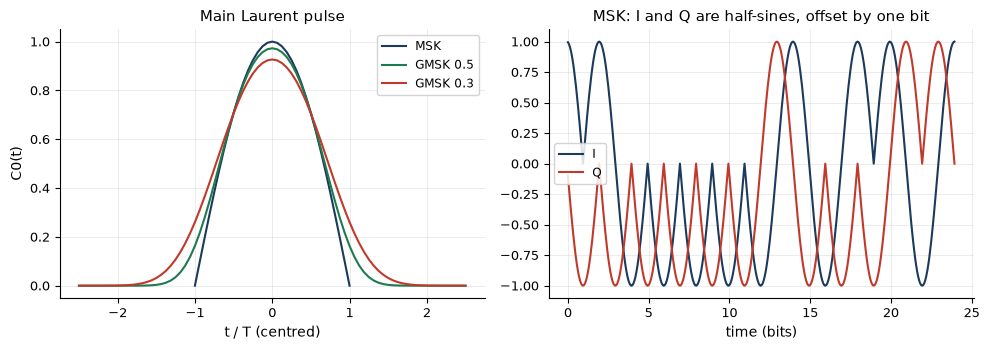

In [9]:
sp8 = 16
f, ax = lk.fig("row2", 1, 2)
for BT, col, lab in [(None, lk.NAVY, "MSK"), (0.5, lk.GREEN, "GMSK 0.5"), (0.3, lk.RED, "GMSK 0.3")]:
    c0 = cpm.laurent_c0(sp8, BT)
    ax[0].plot(np.arange(len(c0)) / sp8 - (len(c0) - 1) / sp8 / 2, c0, color=col, label=lab)
ax[0].set_xlabel("t / T (centred)"); ax[0].set_ylabel("C0(t)"); ax[0].legend(); ax[0].set_title("Main Laurent pulse")
c = rng.integers(0, 2, 24)
x, _ = cpm.gmsk_baseband(cpm.msk_precode(c), sp8, None)
t = np.arange(len(x)) / sp8
ax[1].plot(t, x.real, color=lk.NAVY, label="I")
ax[1].plot(t, x.imag, color=lk.RED, label="Q")
ax[1].set_xlabel("time (bits)"); ax[1].legend(); ax[1].set_title("MSK: I and Q are half-sines, offset by one bit")
lk.show(f)

**What you should see.** MSK's $C_0$ is the 2-bit half-sine; GMSK's pulses are smoother and longer (about 3–4 bits wide). On the
right, the I and Q rails of MSK change sign only at alternate bit boundaries, half a symbol apart: the OQPSK structure.

## 4. Detecting MSK and GMSK: coherent, differential, discriminator

* **Coherent (Laurent) receiver**: matched filter to $C_0$, sample once per bit, derotate by $j^{-k}$, take the sign. Needs carrier
  phase and timing (we calibrate them on a known noiseless waveform, which a real receiver would do with a preamble).
* **One-bit differential detector**: $\mathrm{Im}\{y(t)y^*(t-T)\}$: the sign of the phase change over a bit. No carrier recovery.
* **Limiter–discriminator**: the instantaneous frequency integrated over a bit, the cheapest receiver there is (Bluetooth, DECT, pagers).

The two noncoherent receivers need a pre-detection filter (here a one-bit moving average) to limit the noise they see.

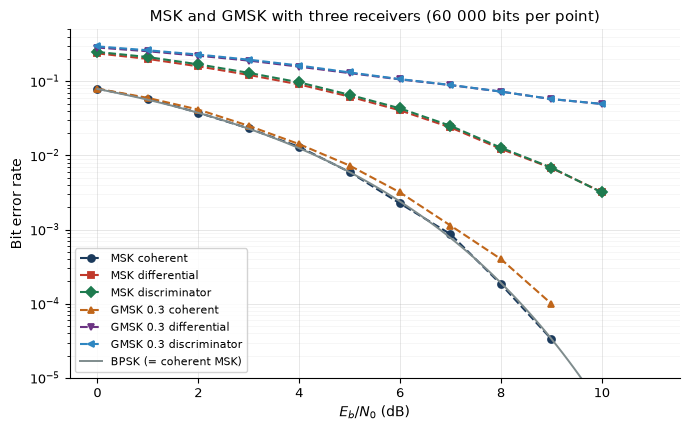

In [11]:
spsd = 8
ebs = np.arange(0, 11, 1.0)
cdat = rng.integers(0, 2, 60_000)
res = {}
for BT in [None, 0.3]:
    a = cpm.msk_precode(cdat)
    x, _ = cpm.gmsk_baseband(a, spsd, BT)
    rx = cpm.LaurentReceiver(spsd, BT); rx.calibrate(x[:8000], cdat[:1000])
    name = "MSK" if BT is None else "GMSK 0.3"
    for e in ebs:
        y, _ = cl.awgn_esn0(x, e, sps=spsd, rng=rng)
        res.setdefault(f"{name} coherent", []).append(np.mean(rx.detect(y, len(cdat))[5:-5] != cdat[5:-5]))
        res.setdefault(f"{name} differential", []).append(np.mean((cpm.differential_detect(y, spsd) > 0)[5:-5] != a[5:-5]))
        res.setdefault(f"{name} discriminator", []).append(np.mean((cpm.discriminator_detect(y, spsd) > 0)[5:-5] != a[5:-5]))
f, ax = lk.fig("ber")
lk.ber_plot(ax, ebs, sims=res, theory={"BPSK (= coherent MSK)": cl.ber_bpsk(np.linspace(0, 11, 100))},
            x_theory=np.linspace(0, 11, 100), ylim=(1e-5, 0.5))
ax.set_title("MSK and GMSK with three receivers (60 000 bits per point)")
lk.show(f)

**What you should see.** Coherent MSK sits on the BPSK curve: constant envelope at no cost in power efficiency. Coherent GMSK 0.3
loses only a few tenths of a dB to its ISI. For MSK the one-bit differential and discriminator receivers (which here give
nearly identical decisions) cost about 4 dB at $10^{-3}$ in exchange for needing no carrier-recovery loop. For GMSK 0.3 these
simple receivers are poor, and their error rate flattens out near $10^{-2}$: the table below shows why. In an alternating
pattern a bit moves the phase only about 28°, not 90°, so a little noise flips the decision. Practical noncoherent GMSK/GFSK
receivers therefore use larger $BT$ (Bluetooth and DECT use 0.5), two-bit differential detection or a small Viterbi detector. GSM
handsets went coherent, with a Viterbi equaliser built on exactly the Laurent model.

In [13]:
rows = []
for BT in [None, 0.5, 0.3, 0.2]:
    _, ph = cpm.gmsk_baseband(rng.integers(0, 2, 4000), spsd, BT)
    step = np.rad2deg(np.abs(np.diff(ph[spsd - 1::spsd])))
    rows.append(["MSK" if BT is None else f"GMSK {BT}", step.min(), np.median(step), step.max()])
lk.table(rows, ["signal", "smallest phase step per bit (deg)", "median", "largest"], fmt=".1f")
#
# ### Interactive: how small can BT go?

signal,smallest phase step per bit (deg),median,largest
MSK,90.0,90.0,90.0
GMSK 0.5,52.7,71.3,90.0
GMSK 0.3,27.6,58.8,90.0
GMSK 0.2,2.1,46.0,90.0


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

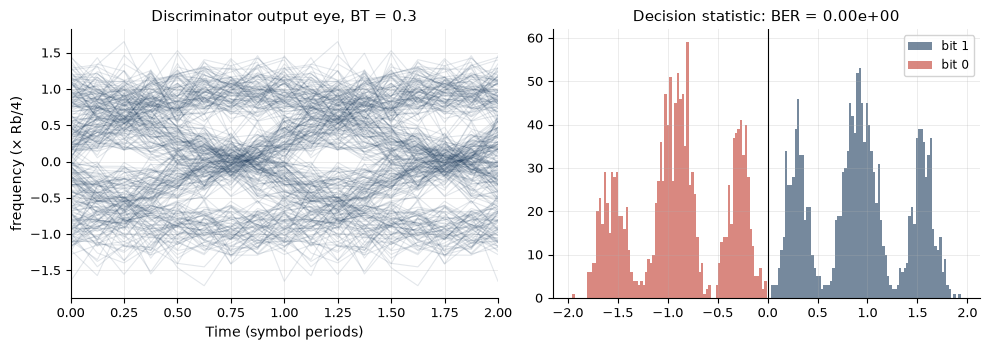

In [14]:
def isi_demo(BT=0.3, ebn0=12.0):
    b = rng.integers(0, 2, 3000)
    x, _ = cpm.gmsk_baseband(b, spsd, BT)
    y, _ = cl.awgn_esn0(x, ebn0, sps=spsd, rng=rng)
    m = spsd
    yf = sps_.lfilter(np.ones(m) / m, 1, y)
    fq = np.angle(yf[1:] * np.conj(yf[:-1])) * spsd / (np.pi / 2)        # normalised instantaneous frequency
    f, ax = lk.fig("row2", 1, 2)
    lk.eye(ax[0], fq, spsd, n_sym=2, offset=spsd // 2, n_traces=300)
    ax[0].set_title(f"Discriminator output eye, BT = {BT:g}"); ax[0].set_ylabel("frequency (× Rb/4)")
    d = cpm.discriminator_detect(y, spsd)
    ber = np.mean((d > 0)[5:-5] != b[5:-5])
    ax[1].hist(d[b == 1], 80, color=lk.NAVY, alpha=0.6, label="bit 1"); ax[1].hist(d[b == 0], 80, color=lk.RED, alpha=0.6, label="bit 0")
    ax[1].axvline(0, color="k", lw=0.8); ax[1].legend(); ax[1].set_title(f"Decision statistic: BER = {ber:.2e}")
    lk.show(f)

lk.interact(isi_demo, BT=lk.slider(0.3, 0.1, 1.0, 0.05, "BT"), ebn0=lk.slider(20, 0, 30, 0.5, "Eb/N0 (dB)"))

**What you should see.** At $BT = 0.3$ the eye is open but its inner traces (alternating bits) are pulled towards zero. Below about
$BT = 0.2$ the discriminator makes errors even without noise: an isolated bit no longer moves the phase far enough.

### Try it yourself 4.1
From the BER table `res`, at which $E_b/N_0$ (dB, integer grid) does coherent GMSK 0.3 first fall below $10^{-3}$?

In [16]:
answer_4_1 = None
lk.check("4.1 Eb/N0 where coherent GMSK 0.3 < 1e-3", answer_4_1,
         ebs[np.argmax(np.array(res["GMSK 0.3 coherent"]) < 1e-3)], atol=1)

[TODO] 4.1 Eb/N0 where coherent GMSK 0.3 < 1e-3: not attempted yet: replace the None with your answer

## 5. Envelope and PAPR

A power amplifier is sized by the signal's peaks, not its average. The **PAPR CCDF** $P(|s|^2/\overline{|s|^2} > x)$ shows how often
the envelope exceeds a level. OQPSK staggers I and Q so the trajectory never passes through zero; π/4-QPSK avoids the origin by
rotating alternate constellations; GMSK has no fluctuation at all.

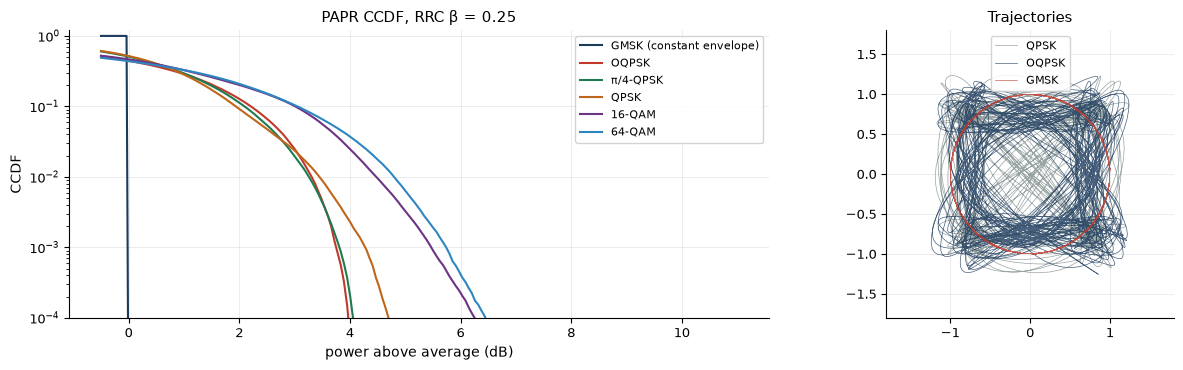

modulation,PAPR at 1e-3 (dB),min |s| / rms
GMSK (constant envelope),-0.02,1.00
OQPSK,3.75,0.28
π/4-QPSK,3.81,0.01
QPSK,4.28,0.00
16-QAM,5.47,0.00
64-QAM,5.74,0.00


In [18]:
grid = np.linspace(-0.5, 11, 200)
kinds = [("gmsk", "GMSK (constant envelope)"), ("oqpsk", "OQPSK"), ("pi4qpsk", "π/4-QPSK"), ("qpsk", "QPSK"),
         ("16qam", "16-QAM"), ("64qam", "64-QAM")]
f, ax = lk.fig((13, 3.8), 1, 2, gridspec_kw=dict(width_ratios=[1.4, 1]))
rows = []
for i, (k, lab) in enumerate(kinds):
    x, _ = cpm.shaped_waveform(k, nsym=30_000, beta=0.25, rng=rng)
    cc = cpm.papr_ccdf(x, grid)
    ax[0].semilogy(grid, np.maximum(cc, 1e-9), color=lk.PALETTE[i], label=lab)
    env = np.abs(x) / np.sqrt(np.mean(np.abs(x) ** 2))
    rows.append([lab, float(np.interp(3, -np.log10(np.maximum(cc, 1e-12)), grid)), env.min()])
ax[0].set_ylim(1e-4, 1.2); ax[0].set_xlabel("power above average (dB)"); ax[0].set_ylabel("CCDF"); ax[0].legend(fontsize=8)
ax[0].set_title("PAPR CCDF, RRC β = 0.25")
for k, col in [("qpsk", lk.GRAY), ("oqpsk", lk.NAVY), ("gmsk", lk.RED)]:
    x, _ = cpm.shaped_waveform(k, nsym=200, beta=0.25, rng=rng)
    x = x / np.sqrt(np.mean(np.abs(x) ** 2))
    ax[1].plot(x.real, x.imag, color=col, lw=0.5, alpha=0.8, label=k.upper())
ax[1].set_aspect("equal"); ax[1].legend(fontsize=8); ax[1].set_title("Trajectories"); ax[1].set_xlim(-1.8, 1.8); ax[1].set_ylim(-1.8, 1.8)
lk.show(f)
lk.table(rows, ["modulation", "PAPR at 1e-3 (dB)", "min |s| / rms"], fmt=".2f")

**What you should see.** GMSK: 0 dB. With RRC pulses OQPSK and π/4-QPSK sit about 0.5 dB below QPSK at $10^{-3}$ (their real
advantage is that the envelope never collapses to zero: see the minimum-envelope column and the trajectories), and the QAMs are
worst at roughly 5.5–6 dB. Every decibel of PAPR is a decibel of back-off and, in a class-AB amplifier, a large slice of
battery life. (OFDM, Chapter 17, is near 9–10 dB.)

### Try it yourself 5.1
From the table, how many dB of extra PAPR (at $10^{-3}$) does 16-QAM have over OQPSK?

In [20]:
answer_5_1 = None
lk.check("5.1 PAPR(16-QAM) - PAPR(OQPSK) at 1e-3 (dB)", answer_5_1, rows[4][1] - rows[1][1], atol=0.3)

[TODO] 5.1 PAPR(16-QAM) - PAPR(OQPSK) at 1e-3 (dB): not attempted yet: replace the None with your answer

## 6. EVM: impairment signatures and a 1024-QAM budget

$\mathrm{EVM}_{\text{rms}}=\sqrt{\sum|y_n-s_n|^2/\sum|s_n|^2}$, and when the errors are noise-like $\mathrm{SNR}\approx 1/\mathrm{EVM}^2$, so a
transmitter with EVM $\epsilon_{tx}$ adds to the receiver's noise: $1/\mathrm{SNR}_{\text{eff}} = 1/\rho+\epsilon_{tx}^2+\epsilon_{rx}^2$.
Each impairment has a signature: phase noise makes arcs (EVM ≈ $\sigma_\phi$ in radians, so 1° ≈ 1.7%), IQ imbalance a parallelogram,
PA compression pulls the corners in, residual frequency offset rotates, and carrier leakage shifts the whole grid.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

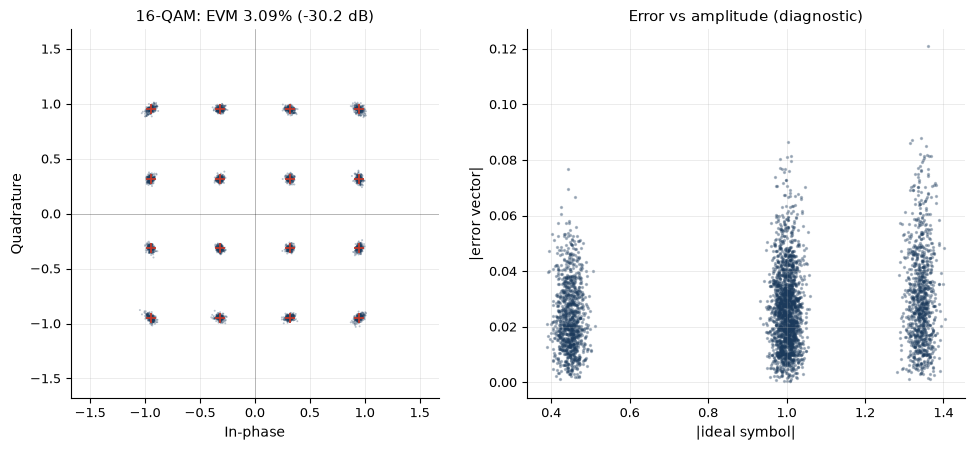

,value
measured EVM (%),3.09
measured EVM (dB),-30.21
effective SNR (dB),30.21
thermal SNR alone (dB),32.00


In [22]:
def evm_demo(constellation="16qam", snr_db=32.0, phase_deg=1.0, iq_gain_db=0.0, iq_phase_deg=0.0, pa_ibo_db=20.0,
             cfo_ppm=0.0, dc=0.0):
    con = cl.get_constellation(constellation)
    N = 4000
    s = con.points[rng.integers(0, con.M, N)]
    y = cpm.rapp_pa_shaped(s, pa_ibo_db) if pa_ibo_db < 19.9 else s.copy()
    y = cpm.phase_noise_awgn(y, phase_deg, rng)
    if iq_gain_db or iq_phase_deg:
        y = cl.iq_imbalance(y, iq_gain_db, iq_phase_deg)
    y = y * np.exp(1j * 2 * np.pi * cfo_ppm * 1e-6 * np.arange(N))
    y = cpm.dc_offset(y, dc)
    y, _ = cl.awgn_esn0(y, snr_db, rng=rng, es=1.0)
    e = cpm.evm(y, s)
    f, ax = lk.fig((10, 4.6), 1, 2, gridspec_kw=dict(width_ratios=[1, 1.1]))
    lk.constellation(ax[0], y, con.points, f"{con.name}: EVM {100 * e:.2f}% ({20 * np.log10(e):.1f} dB)", s=2, alpha=0.3)
    err = y - s
    ax[1].scatter(np.abs(s) + 0.02 * rng.standard_normal(N), np.abs(err), s=2, alpha=0.3, color=lk.NAVY)
    ax[1].set_xlabel("|ideal symbol|"); ax[1].set_ylabel("|error vector|"); ax[1].set_title("Error vs amplitude (diagnostic)")
    lk.show(f)
    lk.table([["measured EVM (%)", 100 * e], ["measured EVM (dB)", 20 * np.log10(e)],
              ["effective SNR (dB)", -20 * np.log10(e)], ["thermal SNR alone (dB)", snr_db]], ["", "value"], fmt=".2f")

lk.interact(evm_demo, constellation=lk.choice(["16qam", "64qam", "256qam", "1024qam"], "16qam", "constellation"),
            snr_db=lk.slider(32, 10, 50, 0.5, "thermal SNR (dB)"), phase_deg=lk.slider(1.0, 0, 10, 0.1, "phase noise (deg rms)"),
            iq_gain_db=lk.slider(0, 0, 3, 0.1, "IQ gain imbalance (dB)"), iq_phase_deg=lk.slider(0, 0, 10, 0.5, "IQ phase error (deg)"),
            pa_ibo_db=lk.slider(20, 0, 20, 0.5, "PA input back-off (dB, 20 = linear)"),
            cfo_ppm=lk.slider(0, 0, 20, 0.5, "residual CFO (ppm of symbol rate)"), dc=lk.slider(0, 0, 0.2, 0.01, "carrier leakage"))

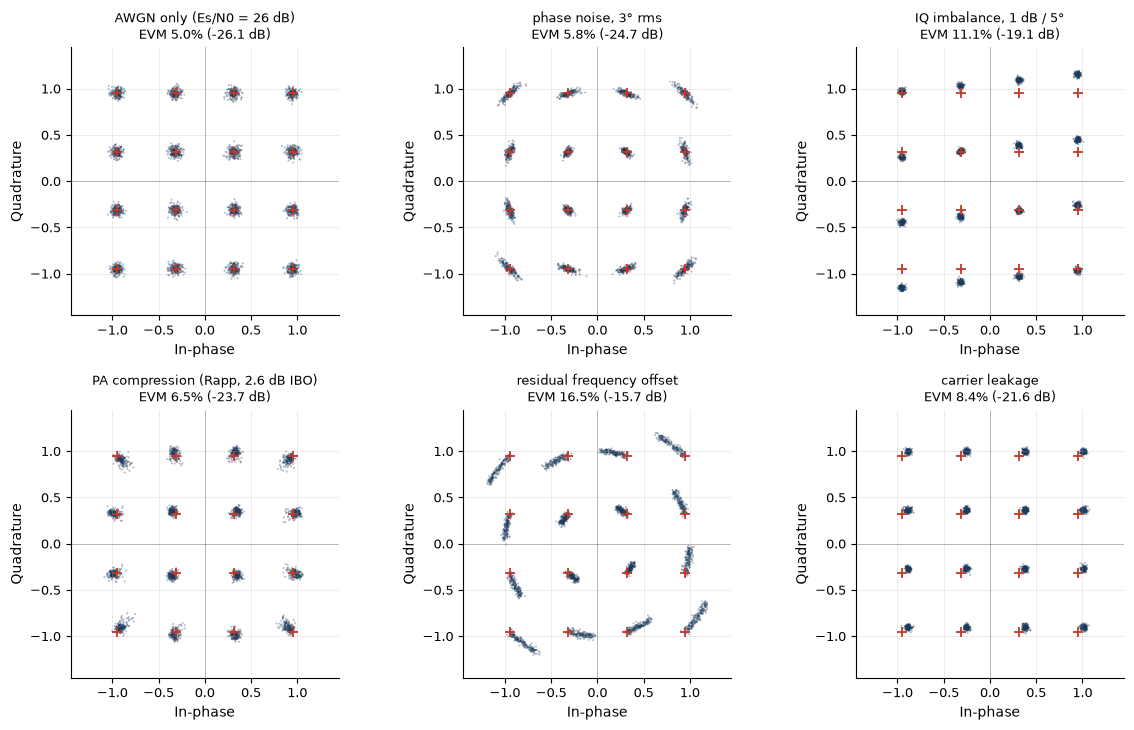

In [23]:
# The gallery of Chapter 9 (Figure ch09_impairments), each with a little noise
con = cl.get_constellation("16qam")
N = 3000
s = con.points[rng.integers(0, 16, N)]
nz = lambda y, snr=32: cl.awgn_esn0(y, snr, rng=rng, es=1.0)[0]
cases = [("AWGN only (Es/N0 = 26 dB)", nz(s, 26)), ("phase noise, 3° rms", nz(cpm.phase_noise_awgn(s, 3, rng))),
         ("IQ imbalance, 1 dB / 5°", nz(cl.iq_imbalance(s, 1.0, 5.0))), ("PA compression (Rapp, 2.6 dB IBO)", nz(cpm.rapp_pa_shaped(s, 2.6))),
         ("residual frequency offset", nz(s * np.exp(1j * 2 * np.pi * 1.5e-5 * np.arange(N)))), ("carrier leakage", nz(cpm.dc_offset(s, 0.08)))]
f, ax = lk.fig((12, 7.4), 2, 3)
for a, (ttl, y) in zip(ax.ravel(), cases):
    lk.constellation(a, y, con.points, None, s=2, alpha=0.35, lim=1.45)
    a.set_title(f"{ttl}\nEVM {100 * cpm.evm(y, s):.1f}% ({cpm.evm_db(y, s):.1f} dB)", fontsize=9)
lk.show(f)

**What you should see.** Each impairment leaves its fingerprint; the error-versus-amplitude panel of the interactive cell tells them
apart quantitatively (phase noise grows linearly with amplitude, compression only at the largest amplitudes, AWGN not at all).
1° of phase noise gives about 1.7% EVM, 3° about 5.2%. Raise the constellation to 1024-QAM and watch how little impairment it tolerates.

**The 1024-QAM budget of Chapter 9.** Target $-35$ dB. Contributions: phase noise 0.5° rms ($-41.2$ dB), image rejection $-45$ dB, PA with
DPD $-38$ dB, DAC/clock/analog $-40$ dB. Error powers add.

contribution,EVM (dB),EVM (%)
phase noise 0.5° rms,-41.2,0.87
IQ image (45 dB IRR),-45.0,0.56
PA with DPD,-38.0,1.26
"DAC, jitter, analog noise",-40.0,1.00
TOTAL,-34.4,1.91
TOTAL with PA backed off 1 dB (-40 dB),-35.1,1.75


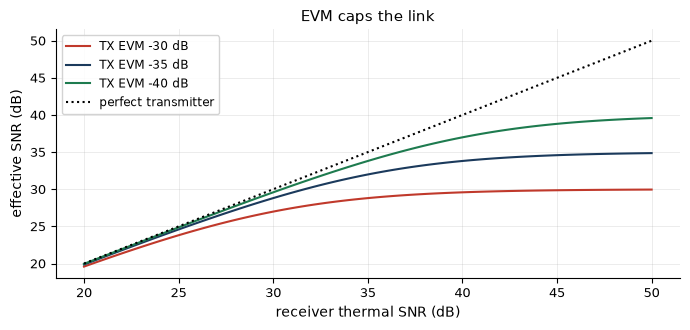

In [25]:
terms = {"phase noise 0.5° rms": 20 * np.log10(np.deg2rad(0.5)), "IQ image (45 dB IRR)": -45.0, "PA with DPD": -38.0,
         "DAC, jitter, analog noise": -40.0}
tot = cpm.evm_budget_db(*terms.values())
tot_backoff = cpm.evm_budget_db(terms["phase noise 0.5° rms"], -45.0, -40.0, -40.0)
lk.table([[k, v, 100 * 10 ** (v / 20)] for k, v in terms.items()] + [["TOTAL", tot, 100 * 10 ** (tot / 20)],
          ["TOTAL with PA backed off 1 dB (-40 dB)", tot_backoff, 100 * 10 ** (tot_backoff / 20)]],
         ["contribution", "EVM (dB)", "EVM (%)"], fmt={1: ".1f", 2: ".2f"}, title="EVM budget, 1024-QAM transmitter (limit -35 dB)")
snr = np.linspace(20, 50, 100)
f, ax = lk.fig((7, 3.4))
for e_tx, col in [(-30, lk.RED), (-35, lk.NAVY), (-40, lk.GREEN)]:
    ax.plot(snr, cpm.snr_eff_db(snr, e_tx), color=col, label=f"TX EVM {e_tx} dB")
ax.plot(snr, snr, "k:", label="perfect transmitter")
ax.set_xlabel("receiver thermal SNR (dB)"); ax.set_ylabel("effective SNR (dB)"); ax.legend(); ax.set_title("EVM caps the link")
lk.show(f)

**What you should see.** The budget totals $-34.4$ dB (1.91%) and fails; backing the PA off by a dB (to $-40$ dB) brings it to
$-35.1$ dB and it passes with no margin, exactly as in the chapter. The right-hand plot is the reason the number matters: a
transmitter at $-35$ dB caps the effective SNR at 35 dB however close the client sits.

### Try it yourself 6.1
What rms phase noise (degrees) alone gives an EVM of $-35$ dB? (Use EVM ≈ $\sigma_\phi$ in radians.)

In [27]:
answer_6_1 = None
lk.check("6.1 phase noise for -35 dB EVM (deg rms)", answer_6_1, np.rad2deg(10 ** (-35 / 20)), atol=0.03)

[TODO] 6.1 phase noise for -35 dB EVM (deg rms): not attempted yet: replace the None with your answer

## Key takeaways
* CPM keeps the envelope constant and the phase continuous; $h$ and the frequency pulse ($BT$) set spectrum and ISI.
* MSK is OQPSK with half-sine pulses: constant envelope at BPSK's power efficiency. GMSK 0.3 fits in 0.91 $R_b$ (99%) for a few tenths of a dB.
* Noncoherent (differential, discriminator) receivers cost several dB but need no carrier recovery.
* PAPR ranks modulations by amplifier friendliness: GMSK 0 dB, OQPSK and π/4-QPSK ~3–4 dB, QAM 5–6 dB, OFDM ~9–10 dB.
* EVM is an SNR in disguise; impairments add as error powers, and the transmitter's EVM caps the link.

## Going further (hardware: USRP B200 / GNU Radio)
* Generate GMSK with GNU Radio's `GMSK Mod` block (BT = 0.3) into the B200 through a 30 dB attenuator, capture it with
  `gr01_spectrum_iq_capture.py`, and measure its 99% bandwidth with `cpm.occupied_bandwidth`. Compare with this lab.
* Transmit 64-QAM from `gr02_psk_link.py` (change the constellation) at several TX gains and measure EVM with `cpm.evm` after
  the receiver's equaliser: find the gain at which the B200's PA starts to compress.

## Exercises
1. **(Warm-up)** Show numerically that MSK generated by `gmsk_baseband(bits, sps, None)` equals OQPSK with half-sine pulses after
   precoding.
2. **(Core)** For $BT$ = 0.5, 0.3 and 0.2, measure the 99% bandwidth and the coherent BER at $10^{-3}$; plot one against the other
   (one of the simulation problems of Chapter 9).
3. **(Core)** Add a Rapp PA to the GMSK and 16-QAM waveforms at 0 dB back-off and compare their spectral regrowth (ACLR).
4. **(Stretch)** Implement multiple-symbol differential detection (two-bit observation) for GMSK and measure how much of the
   coherent/differential gap it recovers.

In [29]:
lk.summary()

[good] Lab 21 finished in 11.0 s. Self-checks: 0 passed, 0 failed, 4 still to do.